In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator
import numpy as np
import matplotlib.ticker as ticker

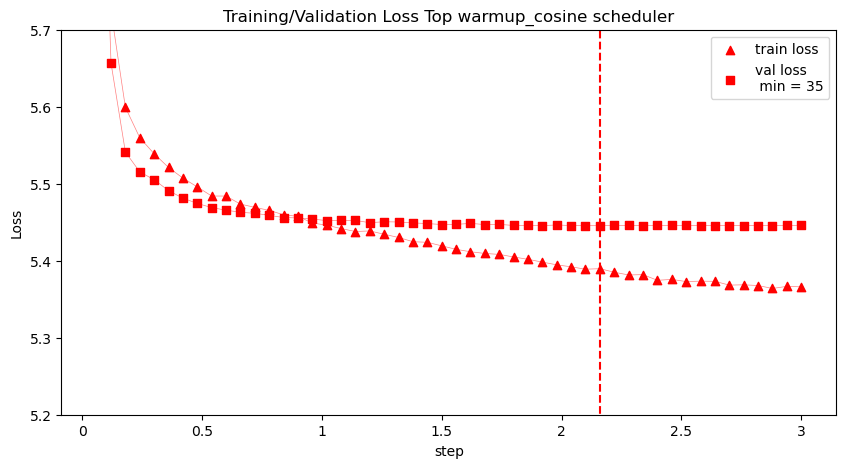

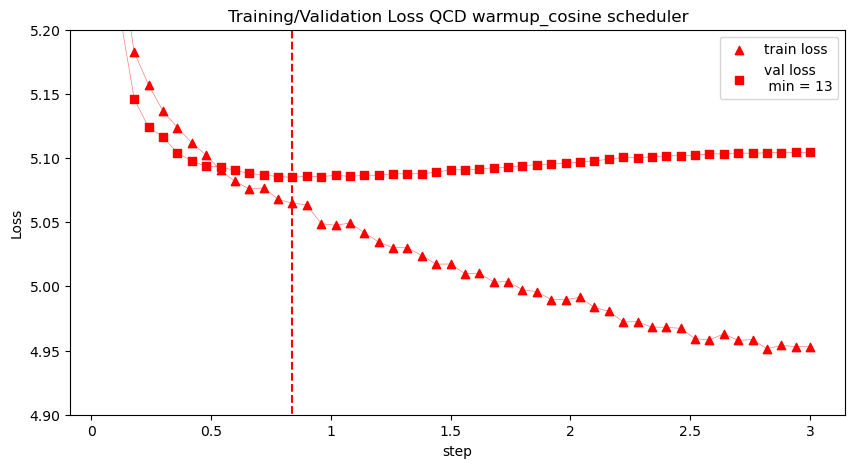

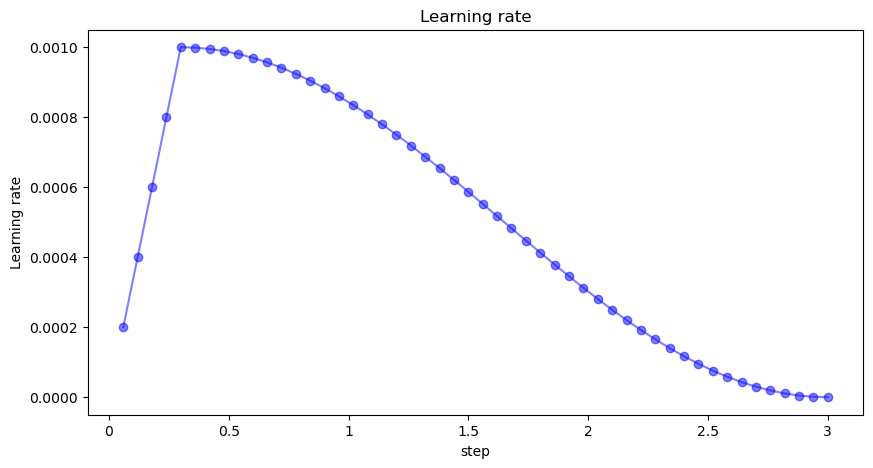

In [4]:
DATASET = "JETCLASS"
SCHEDULER = "warmup_cosine"
N_JETS = 600000

#modify name for specific traings run
folder = f"/hpcwork/rwth0934/hep_foundation_model/training/{DATASET}_{N_JETS}_{SCHEDULER}_128"

qcd = pd.read_csv(f"{folder}/QCD_training_log.csv")
top = pd.read_csv(f"{folder}/TTBar_training_log.csv")

top_min = np.argmin(top["val_loss"])
qcd_min = np.argmin(qcd["val_loss"])

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(top["step"], top["train_loss"], label="train loss",
           color = "red",
           marker = "^")
ax.scatter(top["step"], top["val_loss"], label=f"val loss \n min = {top_min}",
           color = "red",
           marker = "s")

ax.plot(top["step"], top["train_loss"],
           color = "red",
           linewidth = 0.5,
           alpha = 0.5)
ax.plot(top["step"], top["val_loss"],
           color = "red",
           linewidth = 0.5,
           alpha = 0.5)

ax.vlines(top["step"][top_min], 0, 10, color = "red", linestyles="--")

ax.legend()

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/20000:g}")
)
#ax.set_yscale("log")
ax.set_title(f"Training/Validation Loss Top {SCHEDULER} scheduler")

#ax.set_xlim(0.2, 20)
ax.set_ylim(5.2, 5.7)
ax.set_xlabel("step")
ax.set_ylabel("Loss")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(qcd["step"], qcd["train_loss"], label="train loss",
           color = "red",
           marker = "^")
ax.scatter(qcd["step"], qcd["val_loss"], label=f"val loss \n min = {qcd_min}",
           color = "red",
           marker = "s")

ax.plot(qcd["step"], qcd["train_loss"],
           color = "red",
           linewidth = 0.5,
           alpha = 0.5)
ax.plot(qcd["step"], qcd["val_loss"],
           color = "red",
           linewidth = 0.5,
           alpha = 0.5)

ax.vlines(qcd["step"][qcd_min], 0, 10, color = "red", linestyles="--")

ax.legend()

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/20000:g}")
)
#ax.set_yscale("log")
ax.set_title(f"Training/Validation Loss QCD {SCHEDULER} scheduler")

#ax.set_xlim(0.2, 20)
ax.set_ylim(4.9, 5.2)
ax.set_xlabel("step")
ax.set_ylabel("Loss")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(qcd["step"], qcd["lr"], color = "blue", alpha = 0.5)
ax.scatter(qcd["step"], qcd["lr"], color = "blue", alpha = 0.5)

ax.set_xlabel("step")
ax.set_ylabel("Learning rate")

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/20000:g}")
)

ax.set_title("Learning rate")

plt.show()